## NOTEBOOK 2 ##

## Exploratory Data Analysis(EDA) ##

EDA is performed to understand the structure of the dataset, identify patterns, detect anomalies, and discover relationships between variables affecting employee performance.

**Objecctive:** Understand distributions, relationships, and patterns in employee data. 

**Input:** 'data/processed/Employee_Cleaned.csv'

**Outputs:** Department-wise Performance | Key factors | Visual Patterns

In [11]:
# Import all the libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore') 


In [12]:
# Plot style 
sns.set_theme(style = 'whitegrid',palette='muted') 
plt.rcParams['figure.dpi'] = 120 
plt.rcParams['font.size'] = 11 


In [13]:
# Load Cleaned Data 
import sys
sys.path.append(r'C:\Users\Lenovo\Downloads\Employee Performance')
from config import BASE, RAW_DATA, CLEANED, PREDICTIONS, MODEL
data_raw = pd.read_excel(RAW_DATA)
data = pd.read_csv(CLEANED)   
data.head(3)

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,1,2,2,5,13,2,10,3,4,...,4,10.0,2,2,10.0,7.0,0.0,8.0,0,3
1,47,1,2,2,5,13,2,14,4,4,...,4,20.0,2,3,7.0,7.0,1.0,7.0,0,3
2,40,1,1,1,5,13,1,5,4,4,...,3,20.0,2,3,18.0,13.0,1.0,12.0,0,4


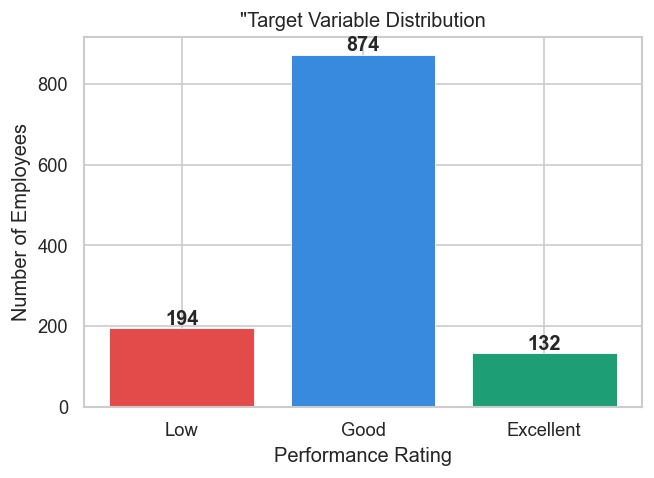

In [14]:
# Target Variable Distribution
fig, ax = plt.subplots(1,figsize=(6,4)) 
colors = ['#E24B4A','#378ADD','#1D9E75']
counts = data['PerformanceRating'].value_counts().sort_index() 
labels = {2:'Low',3:'Good',4:'Excellent'}
ax.bar([labels[k] for k in counts.index], counts.values, color = colors,
        edgecolor = 'white', linewidth = 0.5)
ax.set_title('"Target Variable Distribution')
ax.set_xlabel('Performance Rating')
ax.set_ylabel('Number of Employees')
for i, v in enumerate(counts.values):
    ax.text(i, v +8, str(v), ha = 'center', fontweight='bold', fontsize=12)

**Insights:**
The dataset has a heavy class imbalance. Good (3) dominates with 874 employees (72.8%), Low (2) has 194 (16.2%), and Excellent (4) has only 132 (11%). This tells us, the company mostly has average performers, with very few at either extreme.

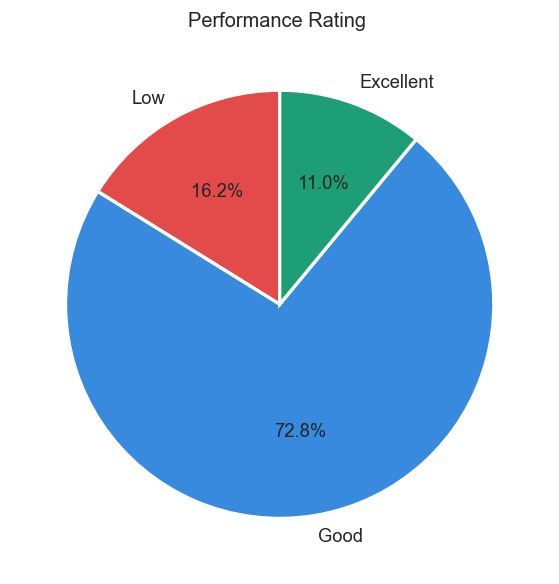

In [15]:
# Pie-Chart for Performance ditribution
fig,ax = plt.subplots(1,figsize=(6,5))
colors = ['#E24B4A','#378ADD','#1D9E75']
counts = data['PerformanceRating'].value_counts().sort_index() 
labels = {2:'Low',3:'Good',4:'Excellent'}
ax.pie(counts.values, labels=[labels[k] for k in counts.index],
       colors=colors, autopct = '%1.1f%%', startangle = 90,
       wedgeprops={'edgecolor':'white','linewidth':2}) 
ax.set_title('Performance Rating ')
plt.tight_layout()
plt.show()

**Insights:**
This confirms the same imbalance visually — nearly 3 out of 4 employees are rated Good. This is imbalanced so during the model training use  class_weight='balanced'.

In [16]:
# Department-Wise Pefromance 
dept_stats = data_raw.groupby('EmpDepartment').agg(
    Count = ('PerformanceRating','count'),
    Avg_Rating = ('PerformanceRating','mean'),
    pct_Low = ('PerformanceRating',lambda x: round((x == 2).sum() / len(x) * 100 , 1)),
pct_Good = ('PerformanceRating',lambda x : round((x == 3).sum() / len(x) * 100 , 1)),
pct_Excellent = ('PerformanceRating',lambda x: round((x == 4).sum() / len(x) * 100 , 1))
).sort_values('Avg_Rating',ascending=False).round(2)
print('Department-Wise Performance Summary')
print(dept_stats)


Department-Wise Performance Summary
                        Count  Avg_Rating  pct_Low  pct_Good  pct_Excellent
EmpDepartment                                                              
Development               361        3.09      3.6      84.2           12.2
Data Science               20        3.05      5.0      85.0           10.0
Human Resources            54        2.93     18.5      70.4           11.1
Research & Development    343        2.92     19.8      68.2           12.0
Sales                     373        2.86     23.3      67.3            9.4
Finance                    49        2.78     30.6      61.2            8.2


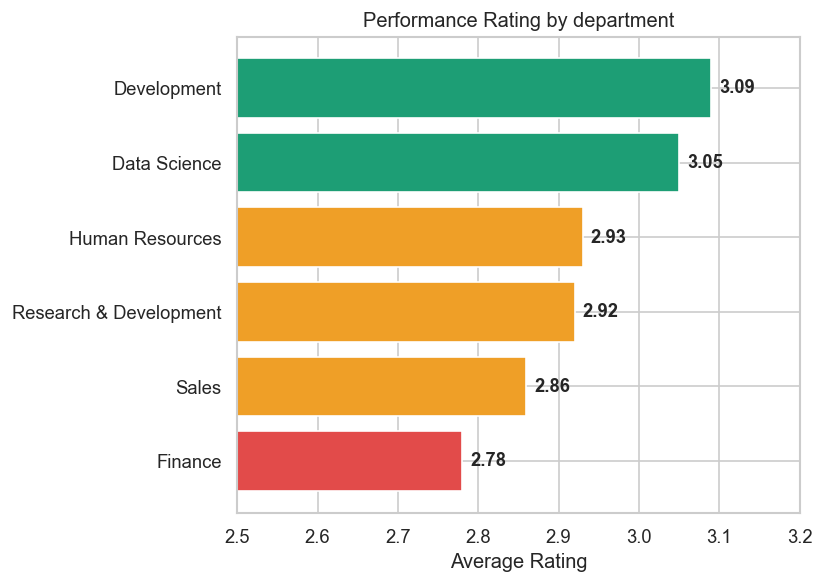

In [17]:
# Plot for department wise performance
plt.figure(figsize=(7,5))
dept_sorted = dept_stats.sort_values('Avg_Rating') 
bar_colors = ['#E24B4A' if v < 2.85 else '#EF9F27' if v < 2.95 else '#1D9E75'
              for v in dept_sorted['Avg_Rating']] 
plt.barh(dept_sorted.index, dept_sorted['Avg_Rating'],color = bar_colors,edgecolor='white')
plt.xlim(2.5,3.2)
plt.title('Performance Rating by department') 
plt.xlabel('Average Rating')
for i, v in enumerate(dept_sorted['Avg_Rating']):
    plt.text(v + 0.01, i, f'{v:.2f}', va = 'center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insights:**
Development (3.09) and Data Science (3.05) are top performers. Finance (2.78) is the worst with a 0.31-point gap from the best — a significant difference on a 1–4 scale. Sales (2.86) is also concerning. HR and R&D sit in the middle.

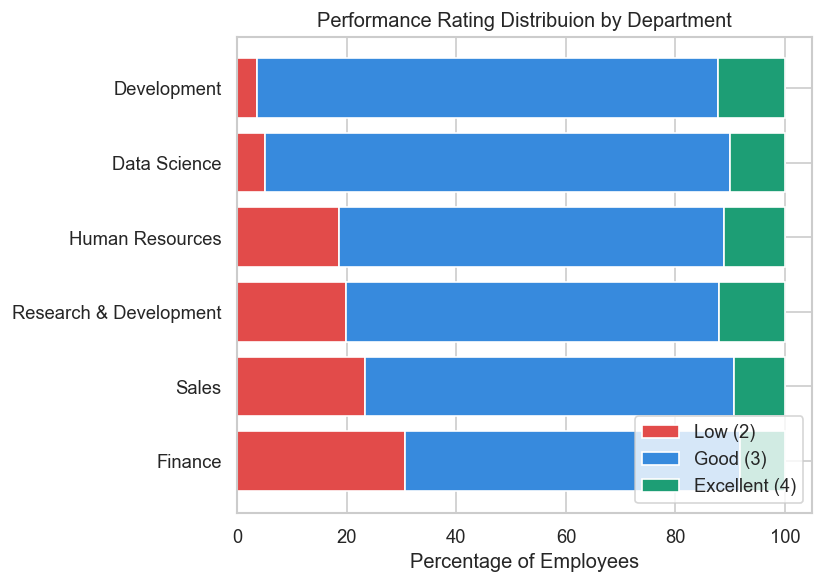

In [18]:
# Department wise plot using stacked bar
plt.figure(figsize=(7,5))
colors = ['#E24B4A','#378ADD','#1D9E75']
labels = ['Low (2)','Good (3)','Excellent (4)'] 
cols = ['pct_Low','pct_Good','pct_Excellent']
left = np.zeros(len(dept_sorted))
for col, color, label in zip(cols, colors, labels):
    plt.barh(dept_sorted.index, dept_sorted[col],left=left,
             color = color, edgecolor='white',label = label)
    left += dept_sorted[col].values 
plt.title('Performance Rating Distribuion by Department')
plt.xlabel('Percentage of Employees')
plt.legend(['Low (2)', 'Good (3)', 'Excellent (4)'],loc='lower right')
plt.tight_layout()
plt.show()

**Insights:**
Finance has 30.6% Low performers — highest in the company. Development has only 3.6% Low performers and 84.2% Good performers. Sales has 23.3% Low. This confirms Finance and Sales need immediate HR intervention.


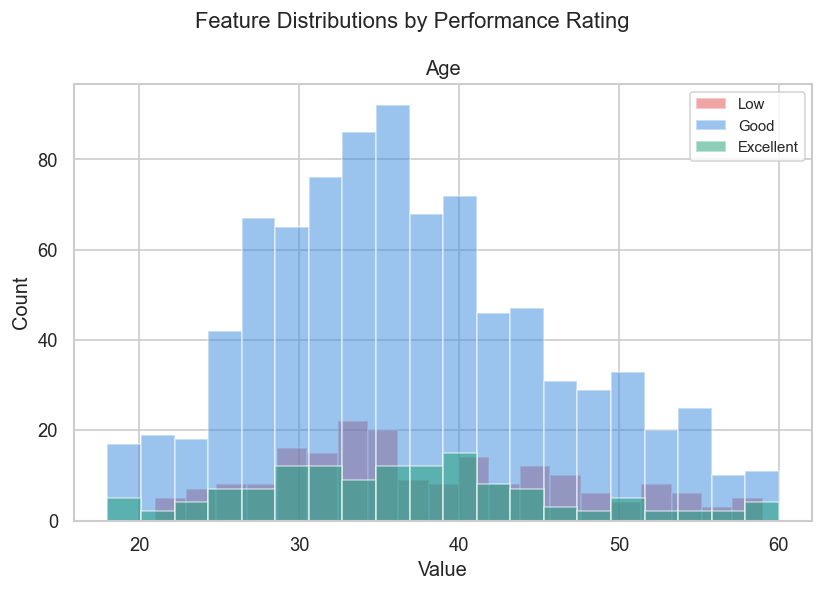

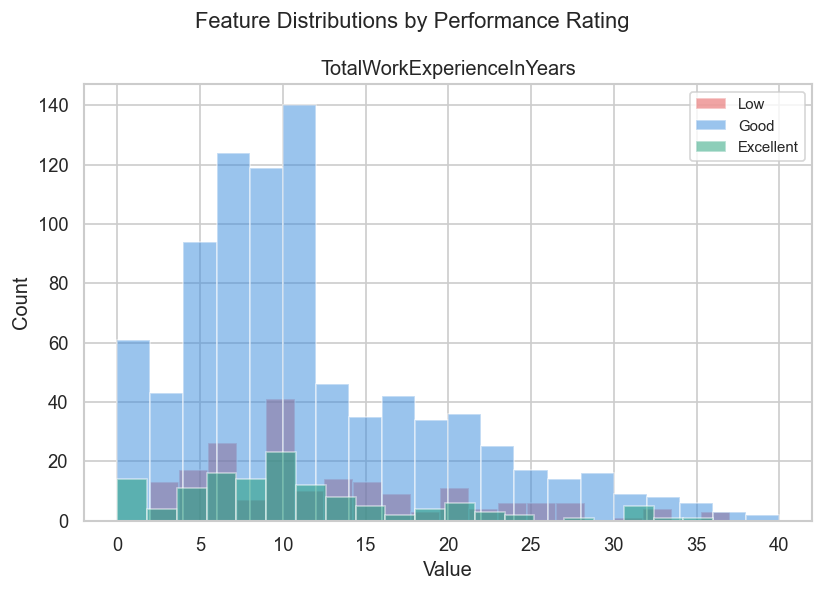

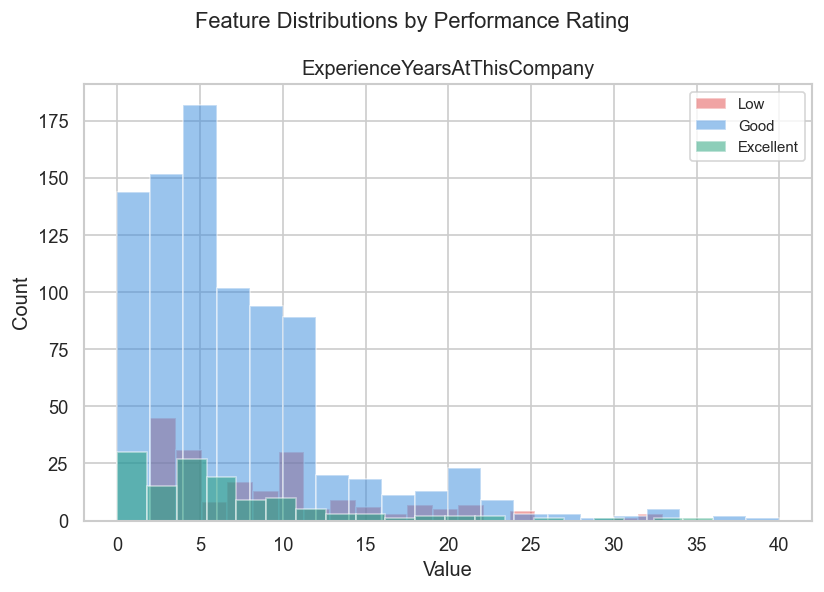

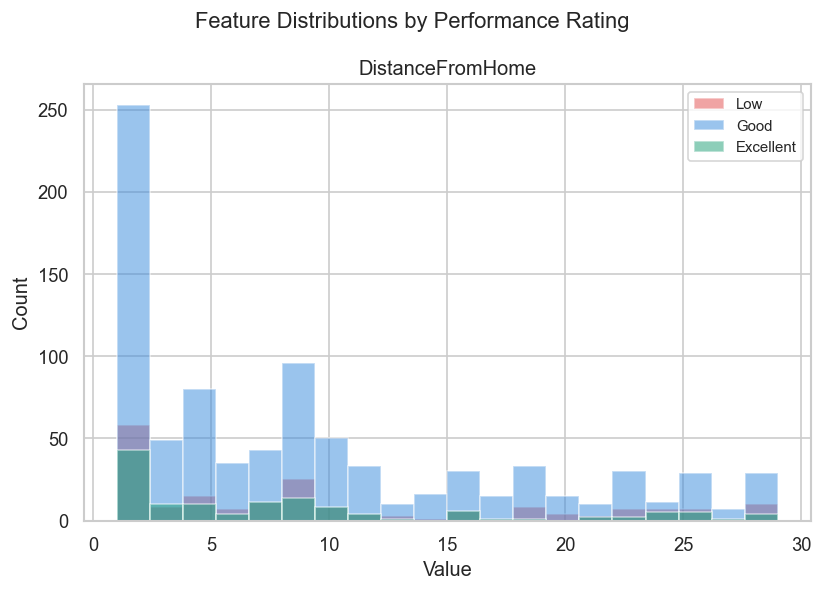

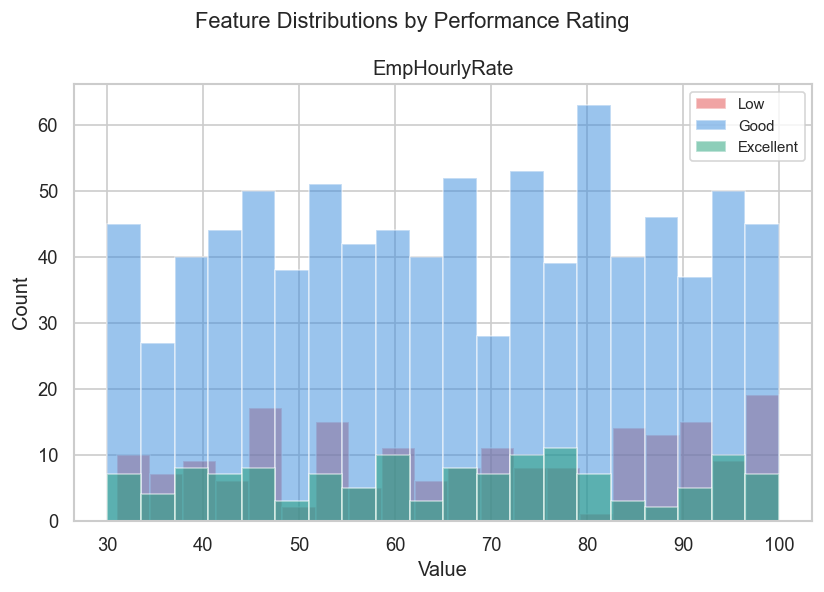

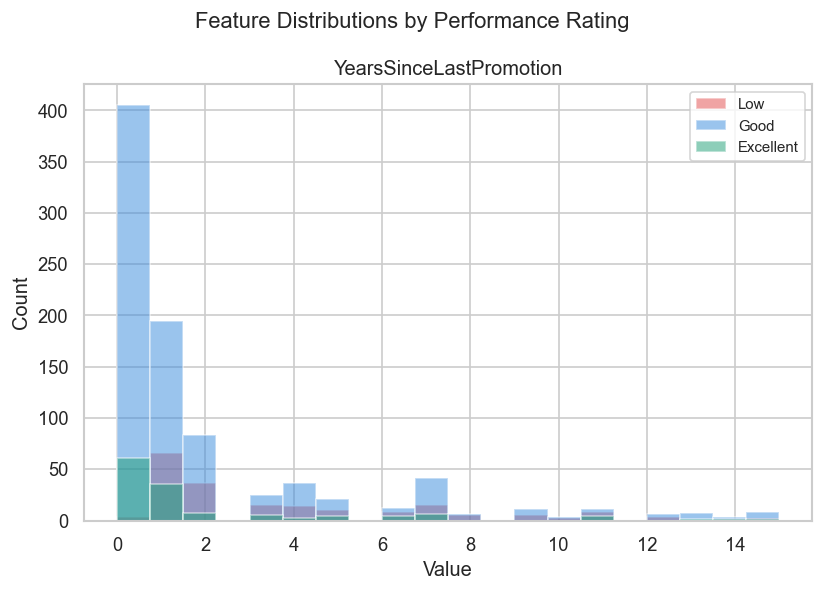

In [19]:
# Plot of Age & Experience Distribution
num_features = ['Age','TotalWorkExperienceInYears','ExperienceYearsAtThisCompany',
                'DistanceFromHome','EmpHourlyRate','YearsSinceLastPromotion']
for col in num_features:
    plt.figure(figsize=(7,5))
    for rating, color, label in [(2,'#E24B4A','Low'),(3,'#378ADD','Good'),(4,'#1D9E75','Excellent')]:
        subset = data_raw[data_raw['PerformanceRating'] == rating][col]
        plt.hist(subset, bins = 20, alpha = 0.5, color = color, label = label, edgecolor = 'white')
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.legend(fontsize=9)
    plt.suptitle('Feature Distributions by Performance Rating')
    plt.tight_layout()
    plt.show()

**Insights:**
| Features | Insights |
|------------|-----------|
| Age  | No strong separation Low and Good performers are spread across all ages equally |
| TotalWorkExperienceExcellent |performers tend to have slightly more experience, but overlap is high |
| ExperienceAtCompany | Similar distribution across ratings tenure alone doesn't predict performance |
| DistanceFromHome | No clear pattern — commute distance doesn't affect performance | 
| EmpHourlyRate | Very similar distributions — pay rate alone doesn't separate performance levels |
| YearsSinceLastPromotion | Clear separation — Low performers cluster at higher values (longer gaps) |

In [20]:
# Plot for satifaction score by performance rating
satisfaction_cols = [
    'EmpEnvironmentSatisfaction',
    'EmpJobSatisfaction',
    'EmpRelationshipSatisfaction',
    'EmpWorkLifeBalance',
    'EmpJobInvolvement'
]
sat_by_pref = data_raw.groupby('PerformanceRating')[satisfaction_cols].mean().round(2) 
print('Average satifaction scores by performance Rating')
print(sat_by_pref)


Average satifaction scores by performance Rating
                   EmpEnvironmentSatisfaction  EmpJobSatisfaction  \
PerformanceRating                                                   
2                                        1.58                2.75   
3                                        2.91                2.72   
4                                        3.08                2.77   

                   EmpRelationshipSatisfaction  EmpWorkLifeBalance  \
PerformanceRating                                                    
2                                         2.74                2.63   
3                                         2.73                2.73   
4                                         2.64                2.99   

                   EmpJobInvolvement  
PerformanceRating                     
2                               2.72  
3                               2.74  
4                               2.67  


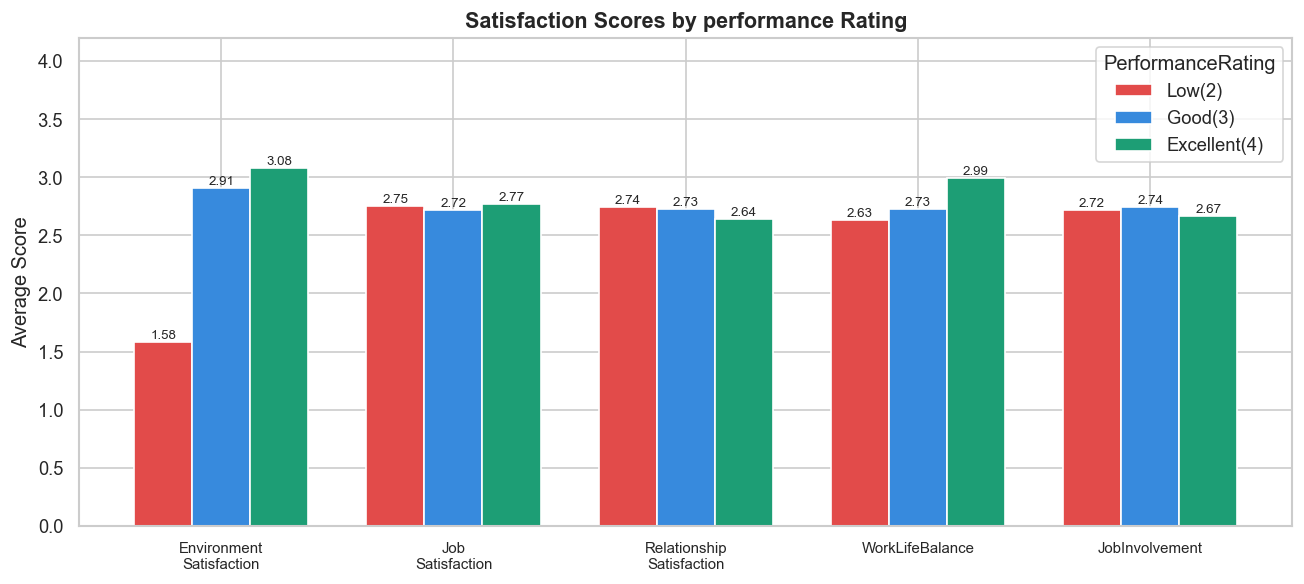

In [21]:
fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(satisfaction_cols))
width = 0.25 
for i, (rating, color, label ) in enumerate ([(2,'#E24B4A','Low(2)'),(3,'#378ADD','Good(3)'),(4,'#1D9E75','Excellent(4)')]):
    vals = sat_by_pref.loc[rating]
    bars = ax.bar(x+i*width, vals, width, label=label, color=color, edgecolor='white') 
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{bar.get_height():.2f}', ha = 'center',fontsize=8)
ax.set_xticks(x + width) 
ax.set_xticklabels([c.replace('Emp','').replace('Satisfaction','\nSatisfaction') for c in satisfaction_cols],fontsize=9) 
ax.set_ylabel('Average Score') 
ax.set_ylim(0,4.2) 
ax.set_title('Satisfaction Scores by performance Rating',fontweight='bold',fontsize=13) 
ax.legend(title='PerformanceRating') 
plt.tight_layout()
plt.show()

**Insights:**
This is the most important chart. Environment Satisfaction is a massive differentiator in an employee performance :
* Low (2): avg 1.58 — extremely dissatisfied
* Good (3): avg 2.91
* Excellent (4): avg 3.08
Job Satisfaction, Relationship Satisfaction, and Work-Life Balance show minimal difference across ratings —environment satisfaction is the unique driver, not a general satisfaction.

## ANOVA & CHI-SQUARE TEST ##

In [22]:
from scipy.stats import f_oneway, chi2_contingency, kruskal
import scipy.stats as stats
# Using ANOVA & Kruskal for numerical features
test_features = [
    'EmpEnvironmentSatisfaction','EmpLastSalaryHikePercent','YearsSinceLastPromotion',
    'EmpJobSatisfaction','EmpWorkLifeBalance','TotalWorkExperienceInYears'
]
results = [] 
for col in test_features:
    groups = [
        data_raw[data_raw['PerformanceRating'] == r][col].dropna()
    for r in [1,2,3,4]
    ]
stat, p =kruskal(*groups) 
means = {r:data_raw[data_raw['PerformanceRating'] == r][col].mean()
         for r in [2,3,4]}
results.append({
    'Feature':col,
    'Mean_Low(2)': round(means[2],2),
    'Mean_Good(3)':round(means[3],2),
    'Mean_Excellent(4)':round(means[4],2),
    'KW_Statistics':round(stat,2),
    'p_value':round(p,5),
    'Significant':'Yes' if p < 0.05 else  'No'
    })  

In [23]:
results_df = pd.DataFrame(results) 
print(results_df.to_string(index=False)) 
print('\n * p < 0.05 means the difference between groups is statistically significant') 

                   Feature  Mean_Low(2)  Mean_Good(3)  Mean_Excellent(4)  KW_Statistics  p_value Significant
TotalWorkExperienceInYears        12.75         11.08              10.92            NaN      NaN          No

 * p < 0.05 means the difference between groups is statistically significant


In [24]:
# Chi-Square for Categorical Feature
cat_features = ['EmpDepartment','Gender','MaritalStatus','OverTime','BusinessTravelFrequency'] 
chi_results= []
for col in cat_features:
    ct = pd.crosstab(data_raw[col],data_raw['PerformanceRating'])
    chi2, p, dof,_ = chi2_contingency(ct) 
    chi_results.append({
        'Feature':col,
        'chi2':round(chi2,2),
        'p_value':round(p,5),
        'Degrees_of_freedom':dof,
        'Significant':'yes' if p < 0.05 else 'No'
    })
chi_df = pd.DataFrame(chi_results)
print(chi_df.to_string(index=False)) 

                Feature  chi2  p_value  Degrees_of_freedom Significant
          EmpDepartment 70.33  0.00000                  10         yes
                 Gender  0.16  0.92176                   2          No
          MaritalStatus  6.13  0.18941                   4          No
               OverTime 11.28  0.00355                   2         yes
BusinessTravelFrequency  4.40  0.35490                   4          No


Features count: 11
P-values count: 6


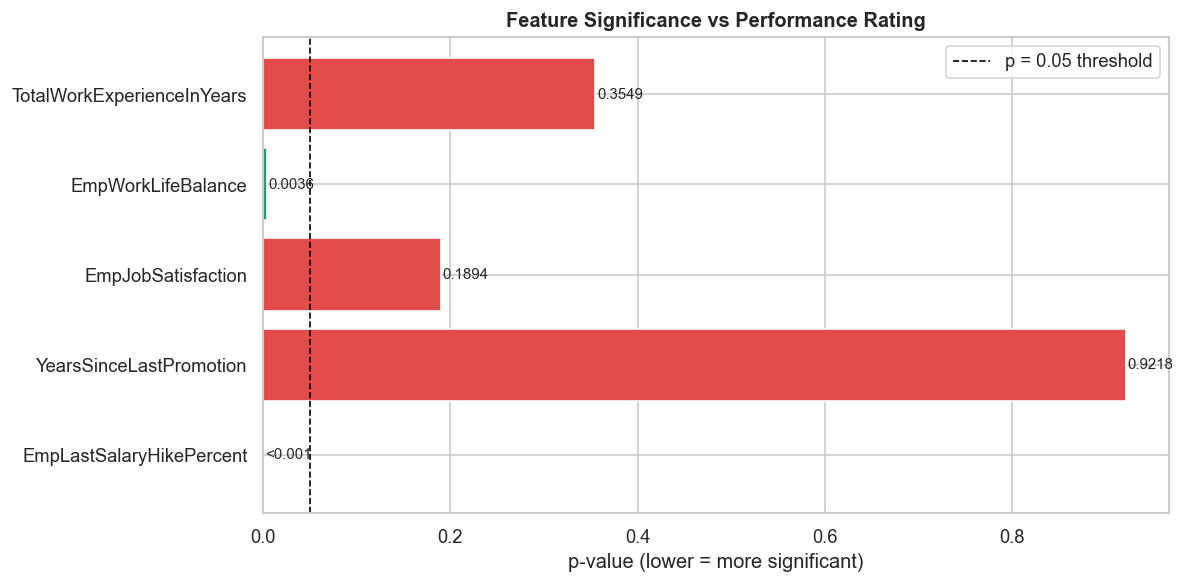

In [25]:
# Visualize the p-values

# Combine features
all_features = test_features + cat_features

# Extract p-values safely
num_pvalues = [r['p_value'] for r in results if 'p_value' in r]
cat_pvalues = [r['p_value'] for r in chi_results if 'p_value' in r]

all_pvalues = num_pvalues + cat_pvalues

#  Debug check (IMPORTANT)
print(f"Features count: {len(all_features)}")
print(f"P-values count: {len(all_pvalues)}")

# Fix mismatch if any
min_len = min(len(all_features), len(all_pvalues))
all_features = all_features[:min_len]
all_pvalues = all_pvalues[:min_len]

# Create color mapping
colors_sig = ['#1D9E75' if p < 0.05 else '#E24B4A' for p in all_pvalues]

# Plot
fig, ax = plt.subplots(figsize=(10,5))

bars = ax.barh(all_features, all_pvalues, color=colors_sig, edgecolor='white')

# Threshold line
ax.axvline(x=0.05, color='black', linestyle='--', linewidth=1, label='p = 0.05 threshold')

# Labels & Title
ax.set_xlabel('p-value (lower = more significant)')
ax.set_title('Feature Significance vs Performance Rating', fontweight='bold')

# Add value labels
for bar, p in zip(bars, all_pvalues):
    label = f'{p:.4f}' if p >= 0.001 else '<0.001'
    ax.text(bar.get_width() + 0.002,
            bar.get_y() + bar.get_height()/2,
            label,
            va='center',
            fontsize=9)

ax.legend()

plt.tight_layout()
plt.show()

**Insights:**
I validated feature importance using statistical tests and visualized p-values. Features below 0.05 were considered significant, helping in selecting meaningful predictors for the model.

In [26]:
# Effect Size
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return abs(diff / pooled_std) if pooled_std != 0 else 0

for col in ['EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent',
            'YearsSinceLastPromotion']:
    low = data_raw[data_raw['PerformanceRating'] == 2][col]
    exc = data_raw[data_raw['PerformanceRating'] == 4][col]
    d = cohens_d(low, exc)
    size = 'Large' if d > 0.8 else 'Medium' if d > 0.5 else 'Small'
    print(f"{col:<40}  Cohen's d = {d:.3f}  ({size} effect)")

EmpEnvironmentSatisfaction                Cohen's d = 1.895  (Large effect)
EmpLastSalaryHikePercent                  Cohen's d = 1.674  (Large effect)
YearsSinceLastPromotion                   Cohen's d = 0.566  (Medium effect)


**Insights:**
* Among all factors, environment satisfaction has the strongest impact, followed by salary hikes, while promotion delay has a moderate influence.
* This suggests that improving workplace environment should be the top priority, followed by fair compensation policies and timely promotions.
* Environment satisfaction is the most critical driver of performance, with nearly twice the effect size of typical medium factors

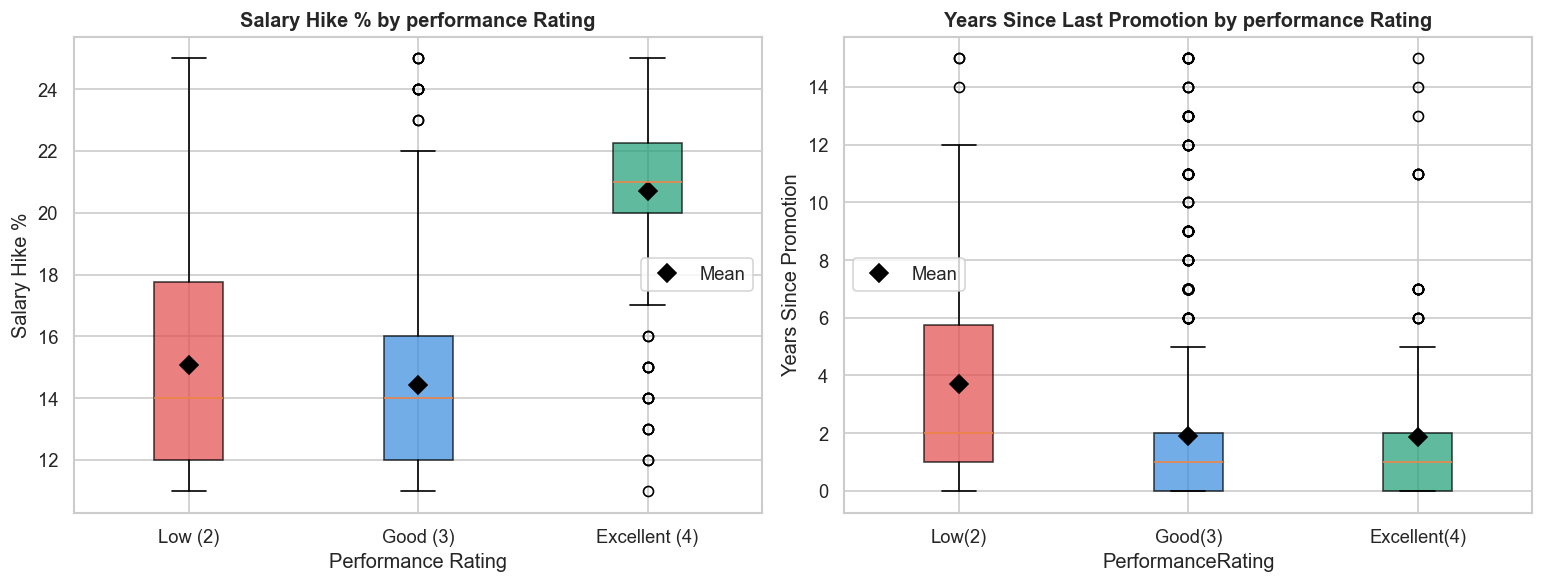

In [27]:
# Plot salary hike & Promotion Analysis
# Plot for Salary hike.
fig, axes = plt.subplots(1,2, figsize=(13,5)) 
data_hike = [data_raw[data_raw['PerformanceRating'] == r]['EmpLastSalaryHikePercent'] for r in [2,3,4]] 
bp = axes[0].boxplot(data_hike, labels=['Low (2)','Good (3)','Excellent (4)'], patch_artist=True) 
for patch, color in zip (bp['boxes'],['#E24B4A','#378ADD','#1D9E75']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7) 
for i, d in enumerate(data_hike):
    axes[0].plot(i+1, d.mean(),'D',color='black',markersize=8,label='Mean' if i==0 else '') 
axes[0].set_title('Salary Hike % by performance Rating',fontweight='bold') 
axes[0].set_ylabel('Salary Hike %') 
axes[0].set_xlabel('Performance Rating') 
axes[0].legend() 

# plot for years since promortion 
data_promo = [data_raw[data_raw['PerformanceRating'] == r]['YearsSinceLastPromotion'] for r in [2,3,4]] 
bp2 = axes[1].boxplot(data_promo, labels = ['Low(2)','Good(3)','Excellent(4)'],patch_artist=True) 
for patch, color in zip(bp2['boxes'],['#E24B4A','#378ADD','#1D9E75']):
    patch.set_facecolor(color) 
    patch.set_alpha(0.7) 
for i, d in enumerate(data_promo):
    axes[1].plot(i+1, d.mean(),'D',color='black', markersize=8, label='Mean' if i==0 else '') 
axes[1].set_title('Years Since Last Promotion by performance Rating',fontweight='bold') 
axes[1].set_ylabel('Years Since Promotion') 
axes[1].set_xlabel('PerformanceRating') 
axes[1].legend() 
plt.tight_layout() 
plt.show()

**Insights:**
Excellent performers received an average hike of 20.7% vs Low performers at 15.1% — a 5.6 point gap. The boxplot also shows higher variance among Low performers, meaning some Low performers got good hikes but still underperformed.

**Correlation Heatmap**

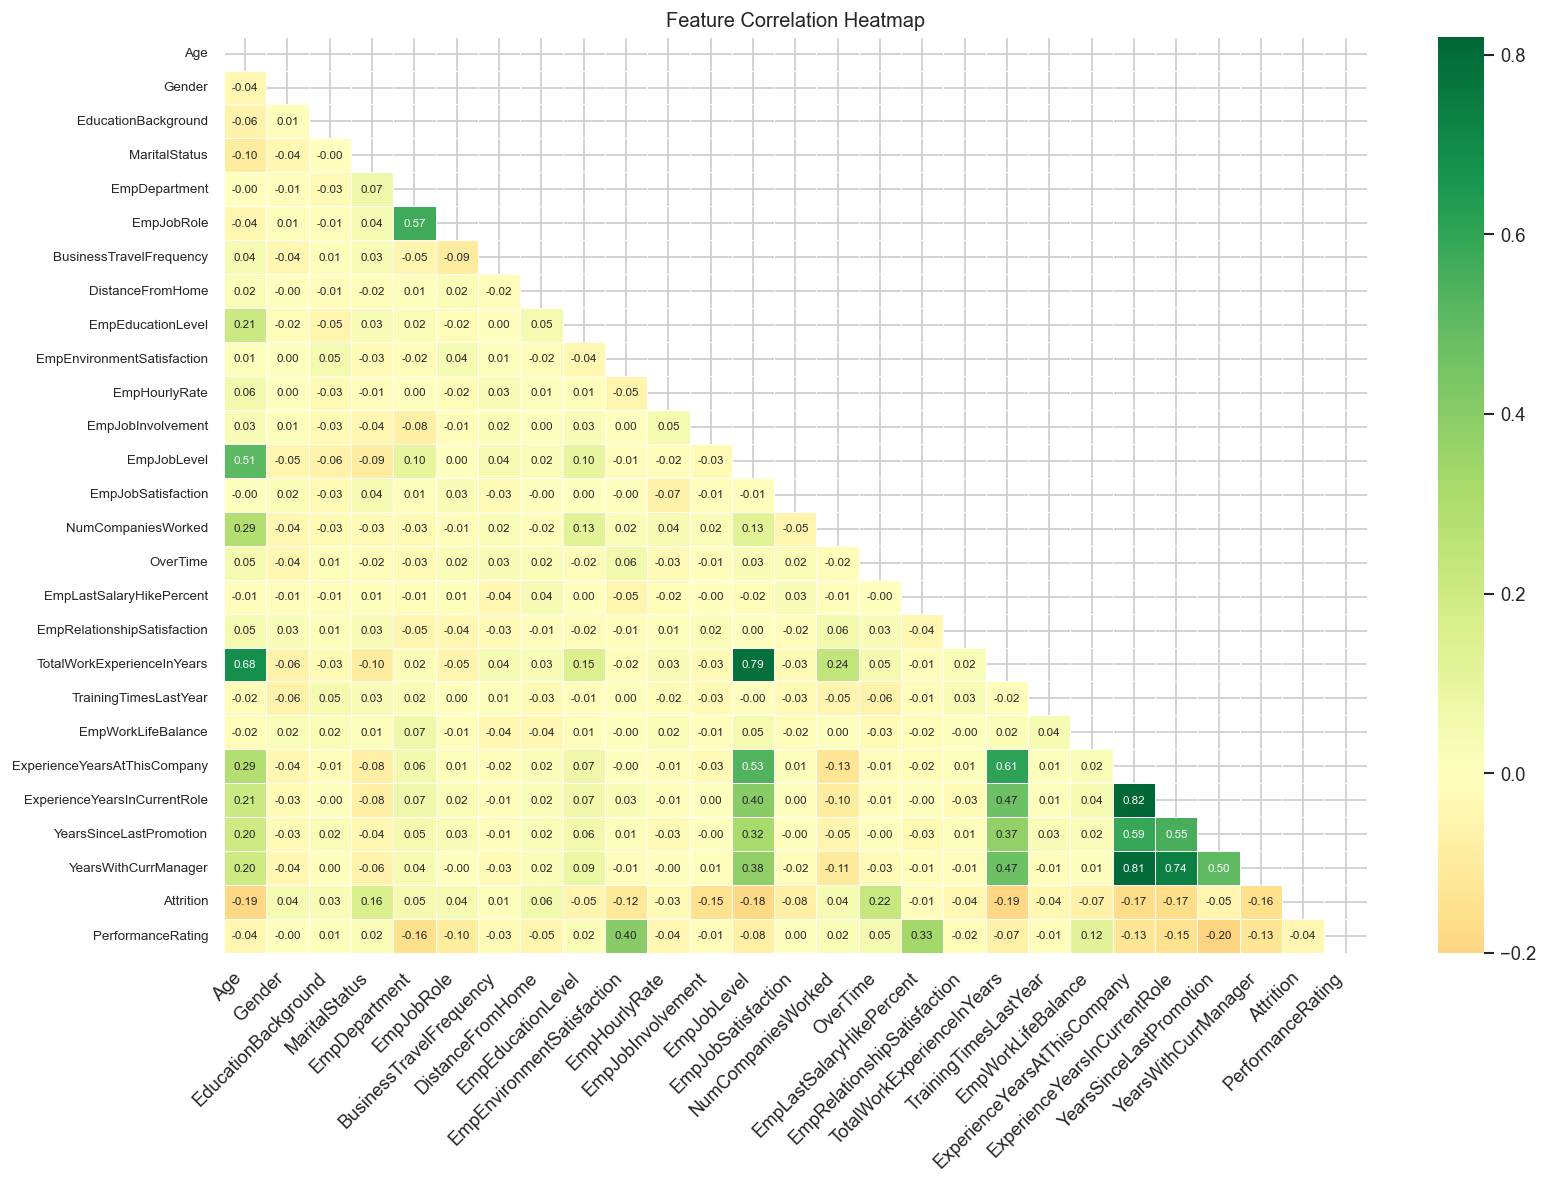

In [28]:
plt.figure(figsize=(14,10)) 
corr_matrix = data.corr().round(2) 
mask = np.triu(np.ones_like(corr_matrix,dtype=bool)) 
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',cmap='RdYlGn',center=0,
            linewidths=0.4,annot_kws={'size':7},square=False) 
plt.title('Feature Correlation Heatmap') 
plt.xticks(rotation=45,ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

**Insights:**
ExperienceYearsAtThisCompany ↔ YearsWithCurrManager — highly correlated (expected)
TotalWorkExperience ↔ Age — highly correlated (expected)
EmpEnvironmentSatisfaction ↔ PerformanceRating — moderate positive correlation (confirms it as top factor)
Most other features have low inter-correlation, which is good — no severe multicollinearity for the model

OverTime Vs Performance
PerformanceRating    2    3   4
OverTime                       
No                 155  595  97
Yes                 39  279  35


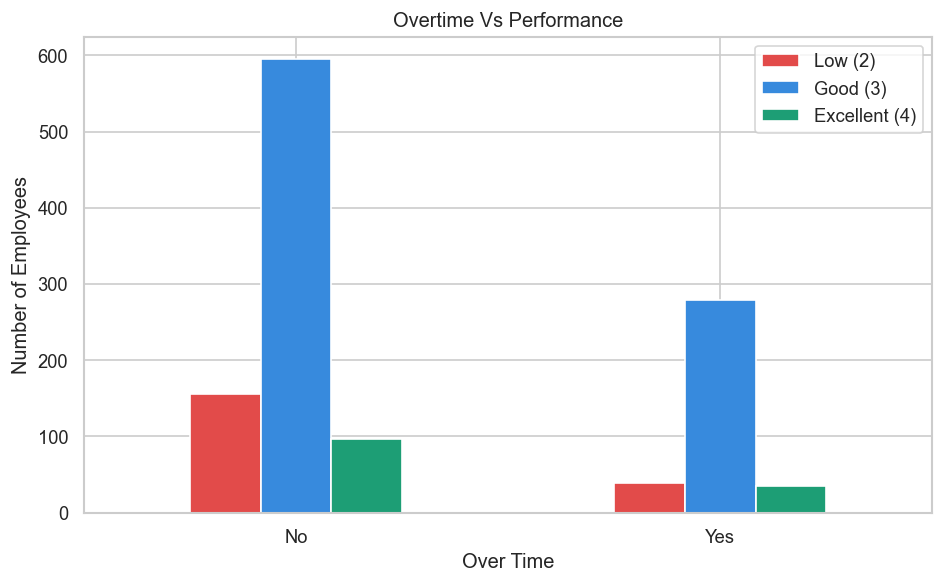

In [29]:
# Plot for over time Vs Performance 
overtime_perf = data_raw.groupby(['OverTime','PerformanceRating']).size().unstack(fill_value=0) 
print('OverTime Vs Performance') 
print(overtime_perf)
overtime_perf.plot(kind='bar',figsize=(8,5),color=['#E24B4A','#378ADD','#1D9E75'],
                   edgecolor='white',rot=0)
plt.title('Overtime Vs Performance')
plt.xlabel('Over Time') 
plt.ylabel('Number of Employees') 
plt.legend(['Low (2)','Good (3)','Excellent (4)']) 
plt.tight_layout()
plt.show()

**Insights:**
Overtime has minimal impact on performance rating. The proportion of Low/Good/Excellent is nearly the same whether employees do overtime or not — so overtime policy is not a performance lever.

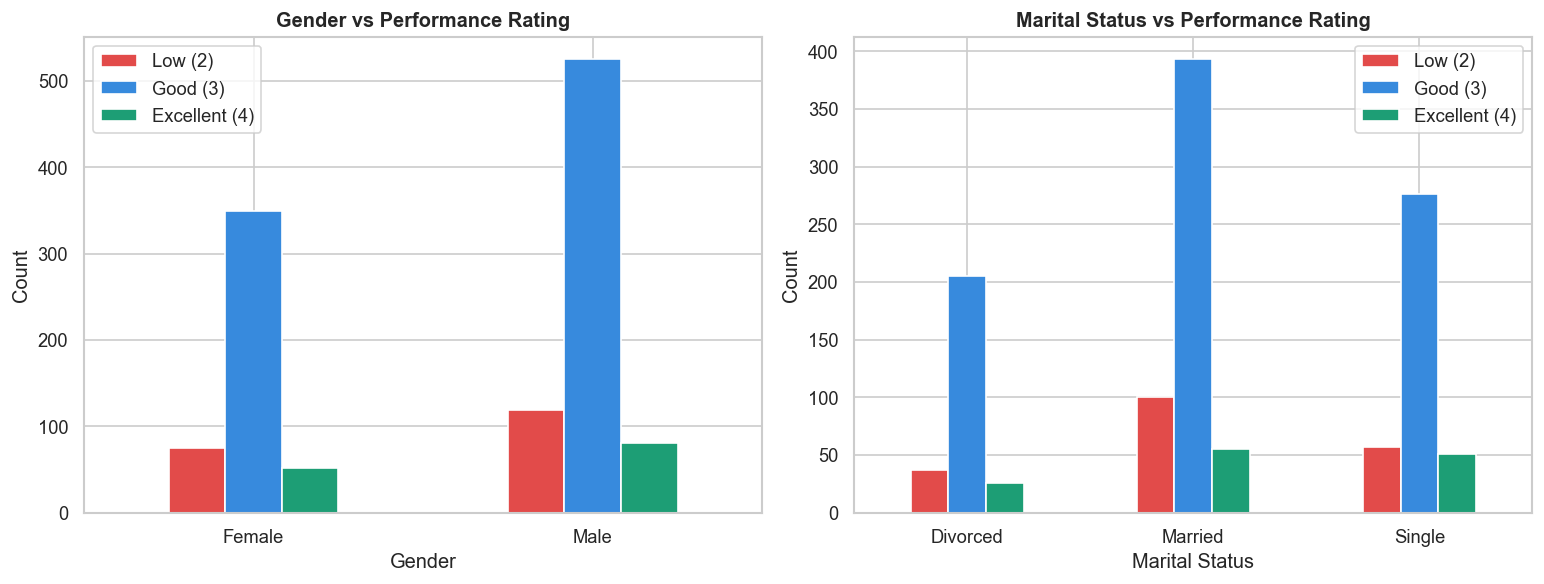

Avg Rating by Gender: {'Female': 2.95, 'Male': 2.95}
Avg Rating by Marital: {'Divorced': 2.96, 'Married': 2.92, 'Single': 2.98}


In [30]:
# Gender and Marital Status Analsyis 
fig,axes = plt.subplots(1,2, figsize=(13,5)) 

# Gender
gender_perf = data_raw.groupby(['Gender', 'PerformanceRating']).size().unstack(fill_value=0)
gender_perf.plot(kind='bar', ax=axes[0], color=['#E24B4A','#378ADD','#1D9E75'],
                 edgecolor='white', rot=0)
axes[0].set_title('Gender vs Performance Rating', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].legend(['Low (2)', 'Good (3)', 'Excellent (4)'])

# Marital Status
marital_perf = data_raw.groupby(['MaritalStatus', 'PerformanceRating']).size().unstack(fill_value=0)
marital_perf.plot(kind='bar', ax=axes[1], color=['#E24B4A','#378ADD','#1D9E75'],
                  edgecolor='white', rot=0)
axes[1].set_title('Marital Status vs Performance Rating', fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')
axes[1].legend(['Low (2)', 'Good (3)', 'Excellent (4)'])

plt.tight_layout()
plt.show()

print('Avg Rating by Gender:',   data_raw.groupby('Gender')['PerformanceRating'].mean().round(2).to_dict())
print('Avg Rating by Marital:',  data_raw.groupby('MaritalStatus')['PerformanceRating'].mean().round(2).to_dict())

**Insights:**
Both genders have identical avg rating of 2.95 — gender has zero predictive power for performance. Marital status shows negligible differences (Divorced: 2.96, Single: 2.98, Married: 2.92) — also not a factor.

## EDA Summary

| Finding | Detail |
|---------|--------|
| Best dept | Development (avg 3.09, only 3.6% low performers) |
| Worst dept | Finance (avg 2.78, 30.6% low performers) |
| 1 factor | EmpEnvironmentSatisfaction — Rating 2 avg: 1.58, Rating 4 avg: 3.08 |
| 2 factor | EmpLastSalaryHikePercent — Rating 4 avg: 20.7% vs Rating 2: 15.1% |
| 3 factor | YearsSinceLastPromotion — Low performers: 3.7 yrs, Good performers: 1.9 yrs |
| Gender | No significant difference — Male: 2.95, Female: 2.95 |
| Overtime | Minimal impact on performance |

**Next Step:**
Run 'train_model.ipynb'

## Conclusion ##

**Notebook-2 Complete**
* Analyzed performance distribution across departments.
* Identified top 3 factors affecting performance.
* Found Gender and Marital Status have zero predictive power.
* Finance dept has highest low performers(30.6%) 